# Benchmark Model 1: Velocities Only (`model_bench_velocities.ipynb`)

This notebook trains a PyTorch LSTM model using **ONLY Transition Velocities** (8 features per step across 4 transition steps: $N, 4, 8$).

## 1. Imports & Hyperparameters Setup

In [40]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Hyperparameters
SEQ_LEN = 4          # 4 velocity steps
FEATURE_DIM = 8      # 8 transition velocities per step
BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_UNITS = 32
DROPOUT = 0.2
EPOCHS = 40

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load & Prepare Datasets (Velocities Only)

In [41]:
def extract_velocity_features(csv_path):
    df = pd.read_csv(csv_path)
    n_samples = len(df)
    X = np.zeros((n_samples, 4, 8), dtype=np.float32)
    
    for v in range(1, 5):
        vel_cols = [
            f"wrist{v}_vx", f"wrist{v}_vy",
            f"mcp{v}_vx", f"mcp{v}_vy",
            f"pip{v}_vx", f"pip{v}_vy",
            f"dip{v}_vx", f"dip{v}_vy"
        ]
        X[:, v - 1, :] = df[vel_cols].fillna(0.0).values.astype(np.float32)
        
    target_col = "touch_finger" if "touch_finger" in df.columns else "touch"
    y = df[target_col].astype(str).str.strip().str.lower().isin(["1", "true", "t", "yes", "y"]).values.astype(np.float32)
    y = y.reshape(-1, 1)
    
    return X, y

TRAIN_CSV = "./data/training_data.csv"
TEST_CSV = "./data/test_data.csv"

X_train_np, y_train_np = extract_velocity_features(TRAIN_CSV)
X_test_np, y_test_np = extract_velocity_features(TEST_CSV)

# Normalize using StandardScaler
scaler = StandardScaler()
N_tr, T, C = X_train_np.shape
N_te, _, _ = X_test_np.shape

X_train_flat = X_train_np.reshape(N_tr, -1)
X_test_flat = X_test_np.reshape(N_te, -1)

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(N_tr, T, C)
X_test_scaled = scaler.transform(X_test_flat).reshape(N_te, T, C)

X_train = torch.from_numpy(X_train_scaled).type(torch.float32)
y_train = torch.from_numpy(y_train_np).type(torch.float32)
X_test = torch.from_numpy(X_test_scaled).type(torch.float32)
y_test = torch.from_numpy(y_test_np).type(torch.float32)

print(f"X_train shape (Velocities Only): {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape  (Velocities Only): {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape (Velocities Only): torch.Size([3206, 4, 8]), y_train shape: torch.Size([3206, 1])
X_test shape  (Velocities Only): torch.Size([486, 4, 8]),  y_test shape:  torch.Size([486, 1])


## 3. DataLoader Setup

In [42]:
class VelocityDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(VelocityDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(VelocityDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 4. LSTM Architecture

In [43]:
class VelocityLSTM(nn.Module):
    def __init__(self, input_features=8, hidden_units=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_features, hidden_size=hidden_units, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_units, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

model_vel = VelocityLSTM(input_features=FEATURE_DIM, hidden_units=HIDDEN_UNITS).to(device)
print(model_vel)

VelocityLSTM(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Training Loop

In [44]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_vel.parameters(), lr=LEARNING_RATE)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    model_vel.train()
    tr_loss, tr_acc = 0.0, 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model_vel(X_b)
        loss = loss_fn(logits, y_b)
        preds = torch.round(torch.sigmoid(logits))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        tr_loss += loss.item() * len(X_b)
        tr_acc += (torch.eq(y_b, preds).sum().item() / len(y_b)) * len(X_b)
        
    train_loss = tr_loss / len(train_loader.dataset)
    train_acc = (tr_acc / len(train_loader.dataset)) * 100.0
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    model_vel.eval()
    te_loss, te_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model_vel(X_b)
            loss = loss_fn(logits, y_b)
            preds = torch.round(torch.sigmoid(logits))
            
            te_loss += loss.item() * len(X_b)
            te_acc += (torch.eq(y_b, preds).sum().item() / len(y_b)) * len(X_b)
            
    test_loss = te_loss / len(test_loader.dataset)
    test_acc = (te_acc / len(test_loader.dataset)) * 100.0
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 01 | Train Loss: 0.6169 | Train Acc: 66.81% | Test Loss: 0.4609 | Test Acc: 79.63%
Epoch: 05 | Train Loss: 0.2970 | Train Acc: 88.68% | Test Loss: 0.3292 | Test Acc: 85.80%
Epoch: 10 | Train Loss: 0.2744 | Train Acc: 89.61% | Test Loss: 0.3201 | Test Acc: 85.80%
Epoch: 15 | Train Loss: 0.2562 | Train Acc: 89.89% | Test Loss: 0.2881 | Test Acc: 87.24%
Epoch: 20 | Train Loss: 0.2410 | Train Acc: 90.74% | Test Loss: 0.3216 | Test Acc: 87.24%
Epoch: 25 | Train Loss: 0.2366 | Train Acc: 90.77% | Test Loss: 0.2826 | Test Acc: 87.45%
Epoch: 30 | Train Loss: 0.2243 | Train Acc: 90.99% | Test Loss: 0.2971 | Test Acc: 87.86%
Epoch: 35 | Train Loss: 0.2105 | Train Acc: 91.64% | Test Loss: 0.3038 | Test Acc: 87.45%
Epoch: 40 | Train Loss: 0.2036 | Train Acc: 91.36% | Test Loss: 0.2900 | Test Acc: 87.65%


## 6. Training & Testing Curves

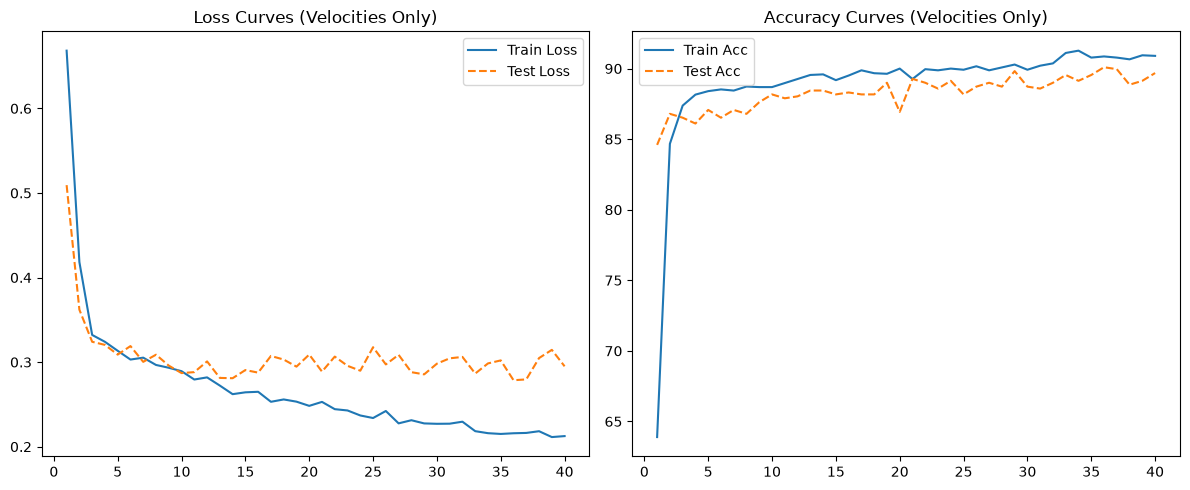

In [28]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss", linestyle="--")
plt.title("Loss Curves (Velocities Only)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label="Train Acc")
plt.plot(range(1, EPOCHS + 1), test_accuracies, label="Test Acc", linestyle="--")
plt.title("Accuracy Curves (Velocities Only)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Evaluation Analytics (Confusion Matrix & Classification Report)


 CONFUSION MATRIX (Velocities Only)
[[351  53]
 [ 20 303]]

Classification Report:
               precision    recall  f1-score   support

 Untouch (0)       0.95      0.87      0.91       404
   Touch (1)       0.85      0.94      0.89       323

    accuracy                           0.90       727
   macro avg       0.90      0.90      0.90       727
weighted avg       0.90      0.90      0.90       727



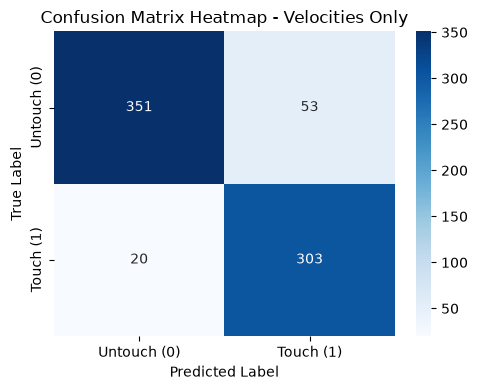

In [34]:
model_vel.eval()
all_preds, all_targets = [], []
with torch.inference_mode():
    for X_b, y_b in test_loader:
        logits = model_vel(X_b.to(device))
        preds = torch.round(torch.sigmoid(logits)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_b.numpy())
        
all_preds = np.array(all_preds).squeeze()
all_targets = np.array(all_targets).squeeze()
cm = confusion_matrix(all_targets, all_preds)
labels = ["Untouch (0)", "Touch (1)"]

print("\n" + "="*50)
print(" CONFUSION MATRIX (Velocities Only)")
print("="*50)
print(cm)
print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=labels))
print("="*50)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Heatmap - Velocities Only")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 8. Save Model Weights

In [8]:
torch.save(model_vel.state_dict(), "finger_touch_velocities.pth")
print("Saved model weights to 'finger_touch_velocities.pth'.")